In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

Number of XVOO_NONE NIR measurements: 10
X_raw shape: (10, 228)


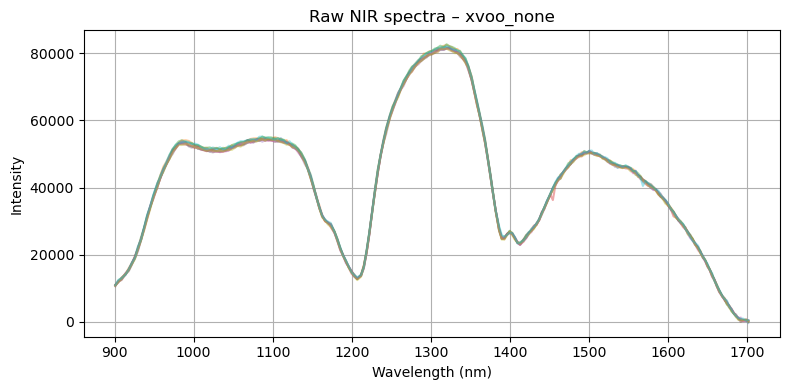

In [34]:
evoo_nir_path = r"data/Replicate_011_20251205/Replicate_011_20251205/xvoo_none/NIR"

files = sorted(glob.glob(os.path.join(evoo_nir_path, "*.csv")))

print(f"Number of XVOO_NONE NIR measurements: {len(files)}")

X_raw = []

for i, fpath in enumerate(files):
    df = pd.read_csv(fpath)

    if i == 0:
        wl = df["x"].values

    X_raw.append(df["y"].values)

X_raw = np.array(X_raw)

print("X_raw shape:", X_raw.shape)

plt.figure(figsize=(8, 4))
for i in range(len(X_raw)):
    plt.plot(wl, X_raw[i], alpha=0.4)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Raw NIR spectra – xvoo_none")
plt.grid(True)
plt.tight_layout()
plt.show()

WR shape: (228, 2)


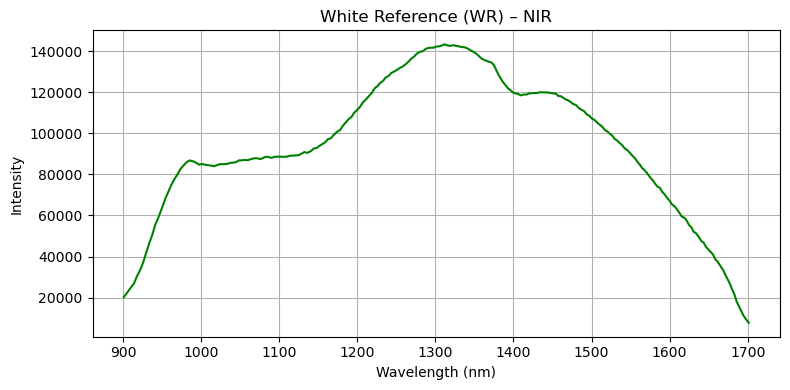

In [35]:
wr_file = r"data/Replicate_011_20251205/Replicate_011_20251205/xvoo_none/wr/NIR_WR.csv"

wr_df = pd.read_csv(wr_file)

wl_wr = wr_df["x"].values
I_wr = wr_df["y"].values

print("WR shape:", wr_df.shape)

assert np.allclose(wl, wl_wr), "XVOO_NONE and WR wavelengths do NOT match!"

plt.figure(figsize=(8, 4))
plt.plot(wl_wr, I_wr, color='green')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("White Reference (WR) – NIR")
plt.grid(True)
plt.tight_layout()
plt.show()

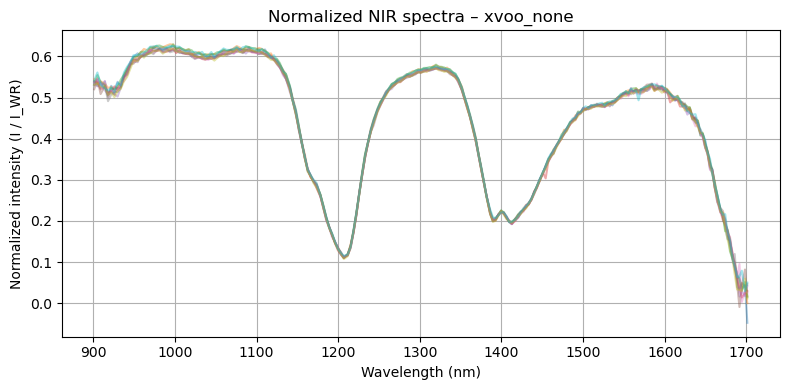

In [36]:
X_norm = X_raw / I_wr_safe

plt.figure(figsize=(8, 4))

for i in range(len(X_norm)):
    plt.plot(wl, X_norm[i], alpha=0.4)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity (I / I_WR)")
plt.title("Normalized NIR spectra – xvoo_none")
plt.grid(True)
plt.tight_layout()
plt.show()